# Comparison of in vitro differentiation with in vivo embryos

In [1]:
here::i_am("rna_atac/clustering/05_vitro_vivo_comparison.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”


In [2]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

# Archr
args$archr_directory = file.path(io$basedir, 'processed/atac/archR')

# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/celltype_markers/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [3]:
# Load meta
meta = fread(args$metadata) %>% 
    .[genotype=='WT']  # Only WT cells for celltype marker search

In [4]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

#### Atlas

In [5]:
atlas_levels = c('PGC', 
                 'Primitive_Streak', 
                 'Nascent_mesoderm', 
                 'Mixed_mesoderm', 
                 'Haematoendothelial_progenitors', 
                 'Endothelium', 
                 'Blood_progenitors_2', 
                 'ExE_mesoderm', 
                 'Mesenchyme',
                 'Allantois')
vitro_levels = c('PGC', 'Primitive_Streak', 'Early_Mes_EOd', 'Early_Mes_EOi', 'HE_Precursor', 'HE', 'Blood_Progenitor', 'Endothelium', 'Posterior_Mes', 'Allantois_Precursor', 'Allantois', 'Mesenchyme')

In [6]:
# Load cell metadata
meta_atlas <- fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/sample_metadata_extended.txt.gz') %>%
  .[,sample:=factor(sample)] 

In [7]:
# # Keep only celltypes of interest
meta_atlas = meta_atlas[celltype %in% atlas_levels]

In [8]:
# Load Atlas
atlas.sce = load_SingleCellExperiment(io$rna.atlas.sce, cells = meta_atlas$cell, normalise = TRUE)

# Get gene metadata
gene_metadata <- fread(io$gene_metadata) %>% .[,c("chr","ens_id","symbol")] %>%
  .[symbol!="" & !is.na(symbol) & ens_id %in% rownames(atlas.sce)] %>%
  .[!duplicated(symbol)]

atlas.sce = atlas.sce[gene_metadata$ens_id]
rownames(atlas.sce) = gene_metadata[match(rownames(atlas.sce), ens_id), symbol]

In [9]:
colData(atlas.sce) = meta_atlas %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

# Convert to Seurat
#atlas.seurat = as.Seurat(atlas.sce)

# Determine correlations

In [10]:
markers = readRDS(file.path(args$outdir, 'Atlas_markers_edgeR.rds')) %>% rbindlist()

In [11]:
head(markers)

gene,logFC,logCPM,F,PValue,FDR,celltype
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Spin2c,5.374069,6.410610,7630.247,0.000000e+00,0.000000e+00,Allantois
Pitx1,7.367281,4.079298,6999.987,8.172827e-314,5.308660e-310,Allantois
Slc38a4,3.503690,5.624871,3980.464,7.476302e-257,3.237488e-253,Allantois
Foxf1,5.179756,5.470746,3823.702,3.370765e-251,1.094740e-247,Allantois
Rgs5,5.530845,3.927606,3720.964,1.259517e-248,3.272478e-245,Allantois
Tmem119,5.178855,3.053924,3460.588,4.775688e-248,1.034016e-244,Allantois


In [12]:
library(BiocParallel)
BPPARAM = MulticoreParam(22)

# Get marker gene list
#markers = markers %>%
#    .[FDR<1e-3 & logFC>1.5]
markers_plot = markers[FDR < 0.05][order(-logFC)] %>% .[,head(.SD, 20), by='celltype']
marker_genes = markers_plot[gene %in% rownames(atlas.sce) & gene %in% rownames(rna.sce), gene]
length(marker_genes)
# marker_genes = intersect(rownames(atlas.sce), rownames(rna.sce)) # test on all genes instead of only on markers
# marker_genes = VariableFeatures(
#     FindVariableFeatures(
#         as.Seurat(
#             atlas.sce[marker_genes,meta_atlas[celltype_updated %in% atlas_levels, cell]]),
#         nfeatures = 1000)) # on hvgs instead

# subset both datasets to marker genes only
atlas_filt = atlas.sce[unique(marker_genes),]
sce_filt = rna.sce[unique(marker_genes),]

# pseudobulk both datasets by celltype
atlas.pb = aggregateAcrossCells(atlas_filt, id=atlas_filt$celltype, statistics="mean", use.assay.type="logcounts", BPPARAM = BPPARAM)
sce.pb = aggregateAcrossCells(sce_filt, id=meta$celltype_v2, statistics="mean", use.assay.type="logcounts", BPPARAM = BPPARAM)

[1] 718

In [13]:
# Perform pairwise correlation between for all celltypes between the 2 datasets 
celltypes_vitro = colnames(sce.pb)
celltypes_atlas = colnames(atlas.pb)

correlations = mclapply(atlas_levels, function(x){
    # Get atlas counts for the celltype
    atlas_counts = as.vector(logcounts(atlas.pb[,x]))
    
    # Correlate with every celltype in chimera object
    calc_correlations = lapply(vitro_levels, function(y){
        vitro_counts = as.vector(logcounts(sce.pb[,y]))
        tmp = data.table(Correlation = cor(atlas_counts, vitro_counts, method='pearson'),
                         atlas = x,
                         vitro = y)
        return(tmp)
    }) %>% rbindlist()
    return(calc_correlations)
}, mc.cores=12) %>% rbindlist() %>% 
    .[,Correlation:=as.numeric(Correlation)] %>% 
    .[,`:=`(atlas=factor(gsub('_', ' ', atlas), levels=gsub('_', ' ', atlas_levels)), vitro=factor(vitro, levels=vitro_levels))] %>% 
    .[,vitro := factor(opts$celltype_v2_figure[match(vitro, names(opts$celltype_v2_figure))], levels = opts$celltype_v2_figure)]

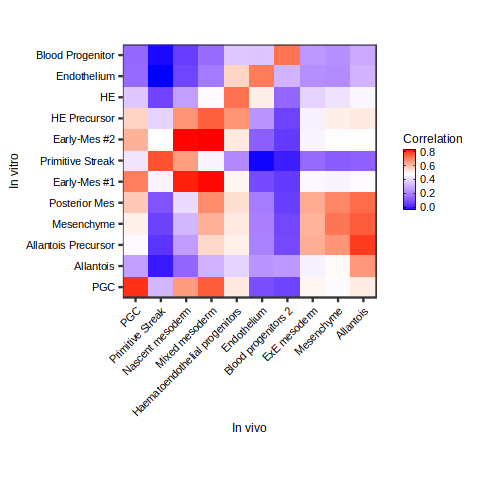

In [14]:
io$outdir = file.path(io$basedir, '/results/thesis/')

p = ggplot(correlations, aes(atlas, vitro, fill=Correlation)) + 
    geom_tile() + 

    #scale_fill_gradientn(colors = c('blue', 'white',  'yellow', 'green', 'red')) + 
    #scale_fill_gradientn(colors=rev(rainbow(3))) +
    scale_fill_gradientn(colors=c('blue', 'white', 'red'), values = c(0,0.6,1)) +
    guides(
        fill = guide_colourbar(
            barwidth = 0.5, barheight = 2.5,
            frame.colour = "black", 
            ticks.colour = "black",
            order = 2, 
        )) + 
               #          limits=c(0,1),
               # breaks = c(0, 0.50, 1)) + 
    scale_x_discrete(expand=c(0,0)) + 
    scale_y_discrete(expand=c(0,0)) + 
    xlab('In vivo') + ylab('In vitro') + 
    coord_fixed(ratio = 10/12) + 
    theme_bw() + 
    theme(axis.text.x = element_text(angle=45, hjust=1, vjust=1, size = 6),
          axis.text.y = element_text(size = 6),
          axis.text = element_text(color='black'),
          axis.title = element_text(size=7),
          legend.text = element_text(size=6),
          legend.title = element_text(size=7),
          panel.border = element_rect(linewidth = 0.5))

options(repr.plot.width=4, repr.plot.height=4)
p
ggsave(file.path(paste0(io$outdir, 'atlas_correlation_RNA_v2.pdf')), 
       plot = p,
       width = 80, 
       height = 60, 
       units = "mm")

# Same for the ATAC

In [15]:
atlas_levels = c('PGC', 
                 'Primitive_Streak', 
                 'Nascent_mesoderm', 
                 'Mixed_mesoderm', 
                 'Haematoendothelial_progenitors', 
                 'Endothelium', 
                 'Blood_progenitors_2', 
                 'ExE_mesoderm', 
                 'Mesenchyme',
                 'Allantois')
vitro_levels = c('PGC', 'Primitive_Streak', 'Early_Mes_EOd', 'Early_Mes_EOi', 'HE_Precursor', 'HE', 'Blood_Progenitor', 'Endothelium', 'Posterior_Mes', 'Allantois_Precursor', 'Allantois', 'Mesenchyme')

In [16]:
vitro_peaks = readRDS(paste0(io$basedir, '/processed/atac/archR/Matrices/PeakMatrix_atlas_summarized_experiment.rds'))

In [17]:
vitro_peaks = vitro_peaks[, meta$cell]

In [18]:
vivo_peaks = readRDS(paste0(io$basedir, '/../atlasses/gastrulation_multiome/data/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds'))

In [19]:
vivo_meta = fread(paste0(io$basedir, '/../atlasses/gastrulation_multiome/results/atac/archR/qc/sample_metadata_after_qc.txt.gz')) %>% 
    .[pass_atacQC == T & doublet_call == F & genotype == 'WT'] %>% 
    .[,celltype_updated := celltype] # %>% 
   # .[,celltype_updated := ifelse(celltype_updated == 'ExE_mesoderm', 'Lateral_plate_mesoderm', celltype_updated)]

In [20]:
vivo_meta = vivo_meta[cell %in% colnames(vivo_peaks)]
vivo_peaks = vivo_peaks[,vivo_meta[celltype_updated %in% atlas_levels, cell]]

In [21]:
vivo_peaks = vivo_peaks[rownames(vitro_peaks)]

In [22]:
summary(rownames(vivo_peaks) == rownames(vitro_peaks))

   Mode    TRUE 
logical  192251 

In [23]:
#
atlas.pb = aggregateAcrossCells(vivo_peaks, id=vivo_meta[match(colnames(vivo_peaks), cell)]$celltype_updated, statistics="mean", use.assay.type="PeakMatrix", BPPARAM = BPPARAM)
sce.pb = aggregateAcrossCells(vitro_peaks, id=meta$celltype_v2, statistics="mean", use.assay.type="PeakMatrix_atlas", BPPARAM = BPPARAM)

In [24]:
assay(atlas.pb,"logcounts") <- log(1e6*(sweep(assay(atlas.pb),2,colSums(assay(atlas.pb),na.rm=T),"/"))+1)
assay(sce.pb,"logcounts") <- log(1e6*(sweep(assay(sce.pb),2,colSums(assay(sce.pb),na.rm=T),"/"))+1)


In [25]:
# Perform pairwise correlation between for all celltypes between the 2 datasets 
celltypes_vitro = colnames(sce.pb)
celltypes_atlas = colnames(atlas.pb)

correlations = mclapply(atlas_levels, function(x){
    # Get atlas counts for the celltype
    atlas_counts = as.vector(atlas.pb@assays@data$logcounts[,x])
    
    # Correlate with every celltype in chimera object
    calc_correlations = lapply(celltypes_vitro, function(y){
        vitro_counts = as.vector(sce.pb@assays@data$logcounts[,y])
        tmp = data.table(Correlation = cor(atlas_counts, vitro_counts, method='pearson'),
                         atlas = x,
                         vitro = y)
        return(tmp)
    }) %>% rbindlist()
    return(calc_correlations)
}, mc.cores=12) %>% rbindlist() %>% 
    .[,Correlation:=as.numeric(Correlation)] %>% 
    .[,`:=`(atlas=factor(atlas, levels=atlas_levels), vitro=factor(vitro, levels=vitro_levels))] %>% 
    .[,vitro := factor(opts$celltype_v2_figure[match(vitro, names(opts$celltype_v2_figure))], levels = opts$celltype_v2_figure)]

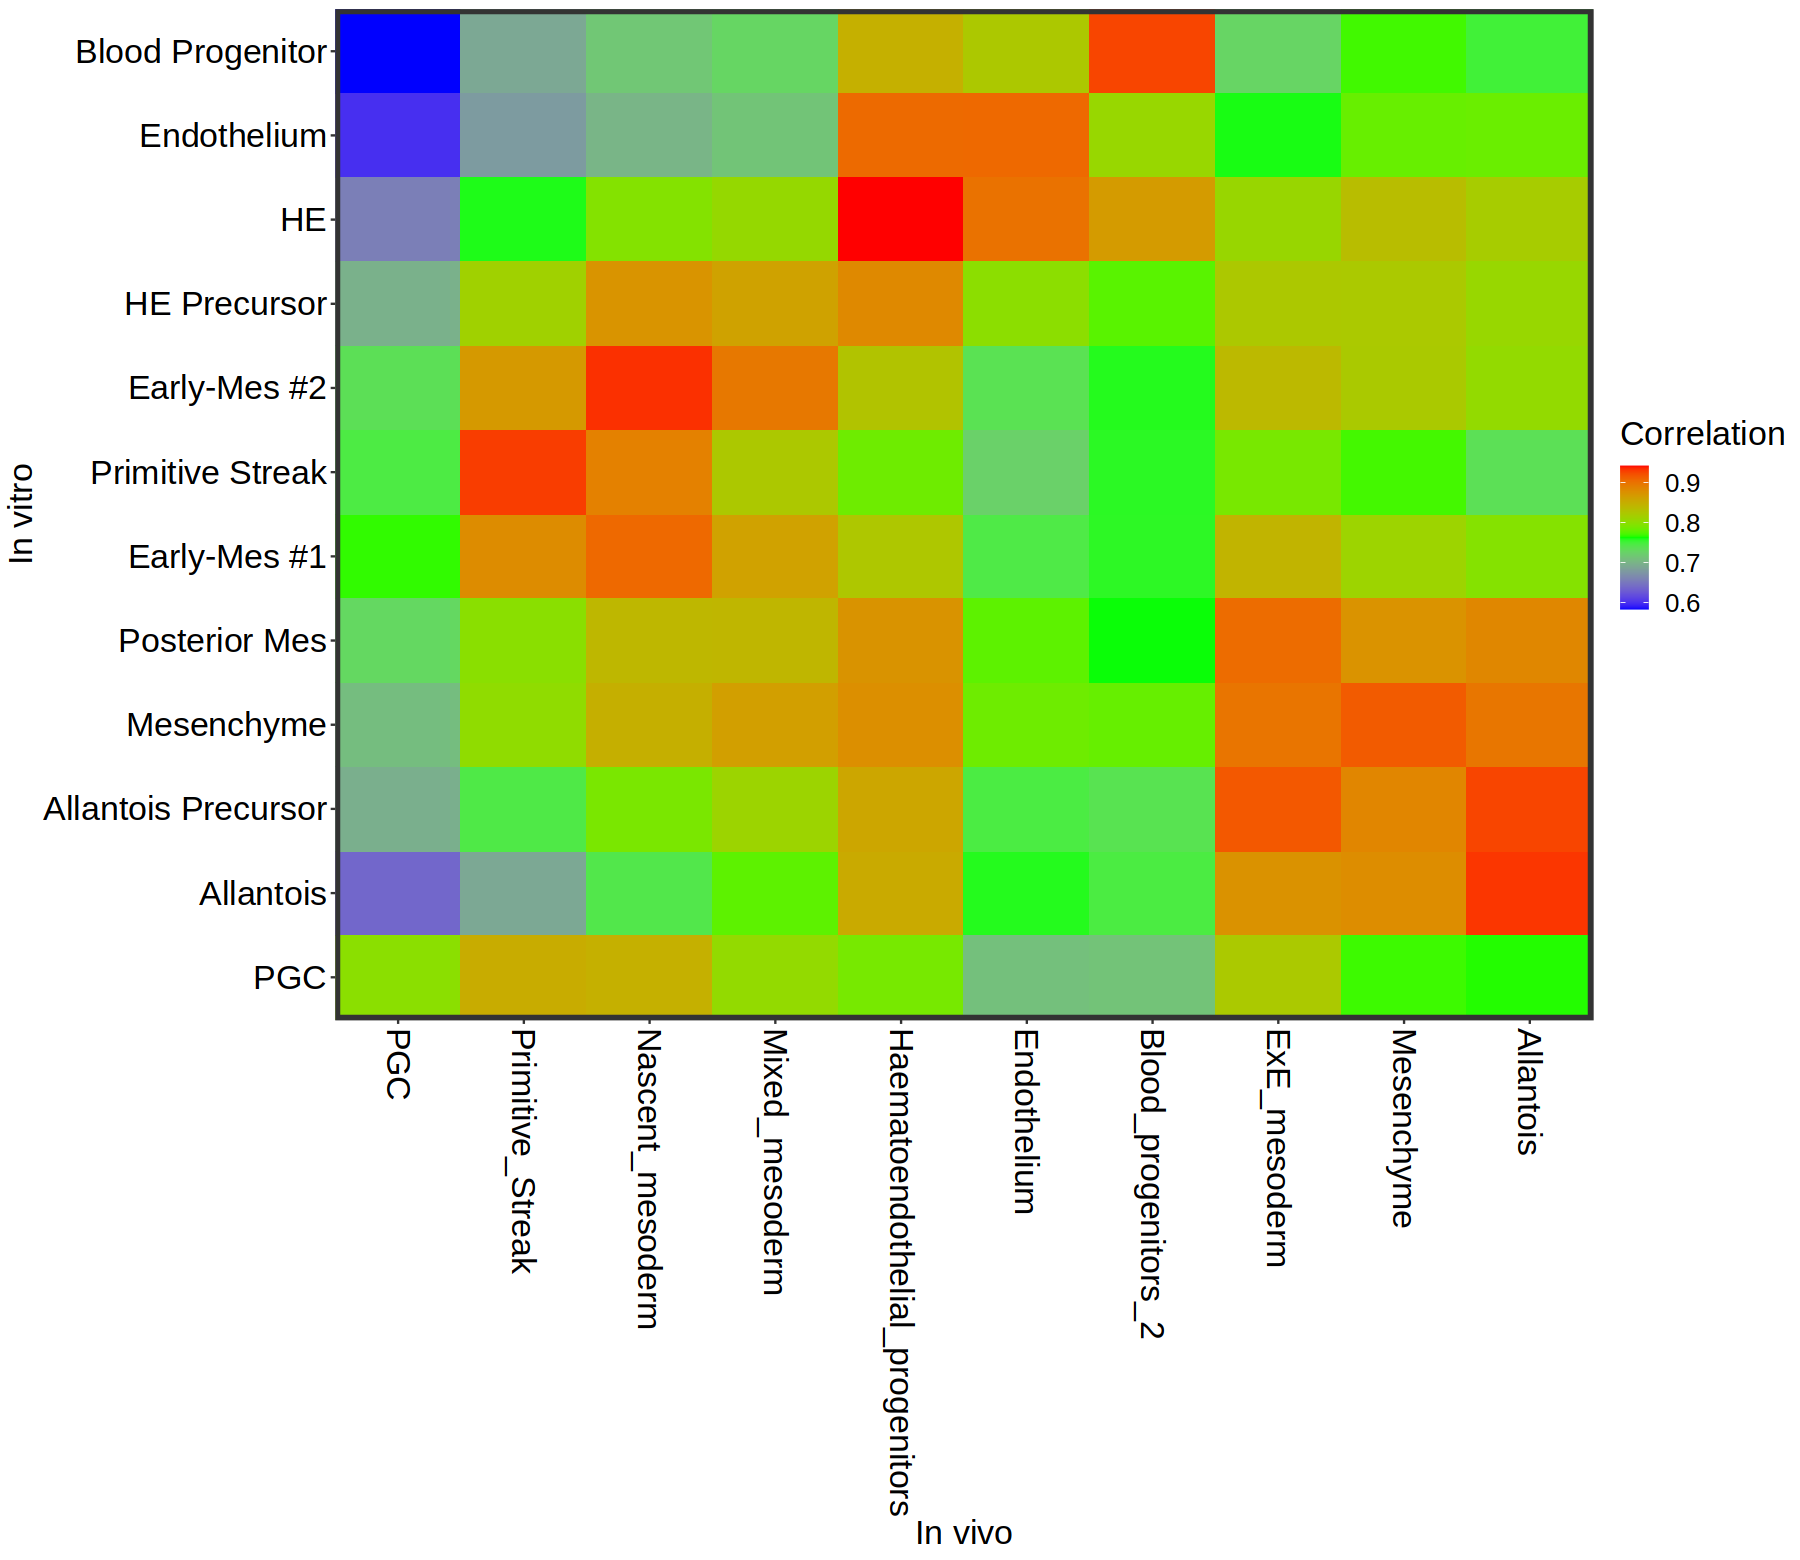

In [26]:
options(repr.plot.width=15, repr.plot.height=13)
p = ggplot(correlations, aes(atlas, vitro, fill=Correlation)) + 
    geom_tile() + 

    #scale_fill_gradientn(colors = c('blue', 'white',  'yellow', 'green', 'red')) + 
    scale_fill_gradientn(colors=rev(rainbow(3))) + 
               #          limits=c(0,1),
               # breaks = c(0, 0.50, 1)) + 
    scale_x_discrete(expand=c(0,0)) + 
    scale_y_discrete(expand=c(0,0)) + 
    xlab('In vivo') + ylab('In vitro') + 
    theme_bw() + 
    theme(axis.text.x = element_text(angle=-90, hjust=0, vjust=0.5),
          axis.text = element_text(color='black', size = 20),
          axis.title = element_text(size=20),
          legend.text = element_text(size=15),
          legend.title = element_text(size=20),
          panel.border = element_rect(linewidth = 2))

# pdf(file.path(io$basedir, '/results/Suppl/mapping_correlation.pdf'), width=15, height=12)
#     print(p)
# dev.off()
p

# ATAC on top markers!

In [27]:
io$outdir = file.path(io$basedir, '/results/thesis/')

p = ggplot(correlations, aes(atlas, vitro, fill=Correlation)) + 
    geom_tile() + 

    #scale_fill_gradientn(colors = c('blue', 'white',  'yellow', 'green', 'red')) + 
    scale_fill_gradientn(colors=rev(rainbow(3))) +
    guides(
        fill = guide_colourbar(
            barwidth = 0.5, barheight = 4.5,
            frame.colour = "black", 
            ticks.colour = "black",
            order = 2, 
        )) + 
               #          limits=c(0,1),
               # breaks = c(0, 0.50, 1)) + 
    scale_x_discrete(expand=c(0,0)) + 
    scale_y_discrete(expand=c(0,0)) + 
    xlab('In vivo') + ylab('In vitro') + 
    theme_bw() + 
    theme(axis.text.x = element_text(angle=-90, hjust=0, vjust=0.5, size = 8),
          axis.text.y = element_text(size = 8),
          axis.text = element_text(color='black', size = 8),
          axis.title = element_text(size=11),
          legend.text = element_text(size=11),
          legend.title = element_text(size=12),
          panel.border = element_rect(linewidth = 2))

ggsave(file.path(paste0(io$outdir, 'atlas_correlation_ATAC.pdf')), 
       plot = p,
       width = 120, 
       height = 120, 
       units = "mm")

In [28]:
vivo_peaks.sce = as(vivo_peaks, 'SingleCellExperiment')

In [29]:
marker_peaks = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/atac/archR/differential/pseudobulk/celltype/PeakMatrix/parsed/markers_filt.txt.gz') %>%
    .[celltype %in% atlas_levels]

In [30]:
nrow(marker_peaks)

[1] 62374

In [31]:
head(marker_peaks)

celltype,feature,score,logFC
<chr>,<chr>,<dbl>,<dbl>
Primitive_Streak,chr10:100111058-100111658,0.86,3.08
Primitive_Streak,chr10:103407173-103407773,0.91,3.85
Primitive_Streak,chr10:106115489-106116089,0.91,3.67
Primitive_Streak,chr10:106461140-106461740,0.91,4.09
Primitive_Streak,chr10:106469285-106469885,0.89,2.07
Primitive_Streak,chr10:10745136-10745736,0.86,3.48


In [32]:
# Perform pairwise correlation between for all celltypes between the 2 datasets 
celltypes_vitro = colnames(sce.pb)
celltypes_atlas = colnames(atlas.pb)

correlations = mclapply(atlas_levels, function(x){
    # Get atlas counts for the celltype
    atlas_counts = as.vector(atlas.pb@assays@data$logcounts[marker_peaks$feature,x])
    
    # Correlate with every celltype in chimera object
    calc_correlations = lapply(celltypes_vitro, function(y){
        vitro_counts = as.vector(sce.pb@assays@data$logcounts[marker_peaks$feature,y])
        tmp = data.table(Correlation = cor(atlas_counts, vitro_counts, method='pearson'),
                         atlas = x,
                         vitro = y)
        return(tmp)
    }) %>% rbindlist()
    return(calc_correlations)
}, mc.cores=12) %>% rbindlist() %>% 
    .[,Correlation:=as.numeric(Correlation)] %>% 
    .[,`:=`(atlas=factor(gsub('_', ' ', atlas), levels=gsub('_', ' ', atlas_levels)), vitro=factor(vitro, levels=vitro_levels))] %>% 
    .[,vitro := factor(opts$celltype_v2_figure[match(vitro, names(opts$celltype_v2_figure))], levels = opts$celltype_v2_figure)]

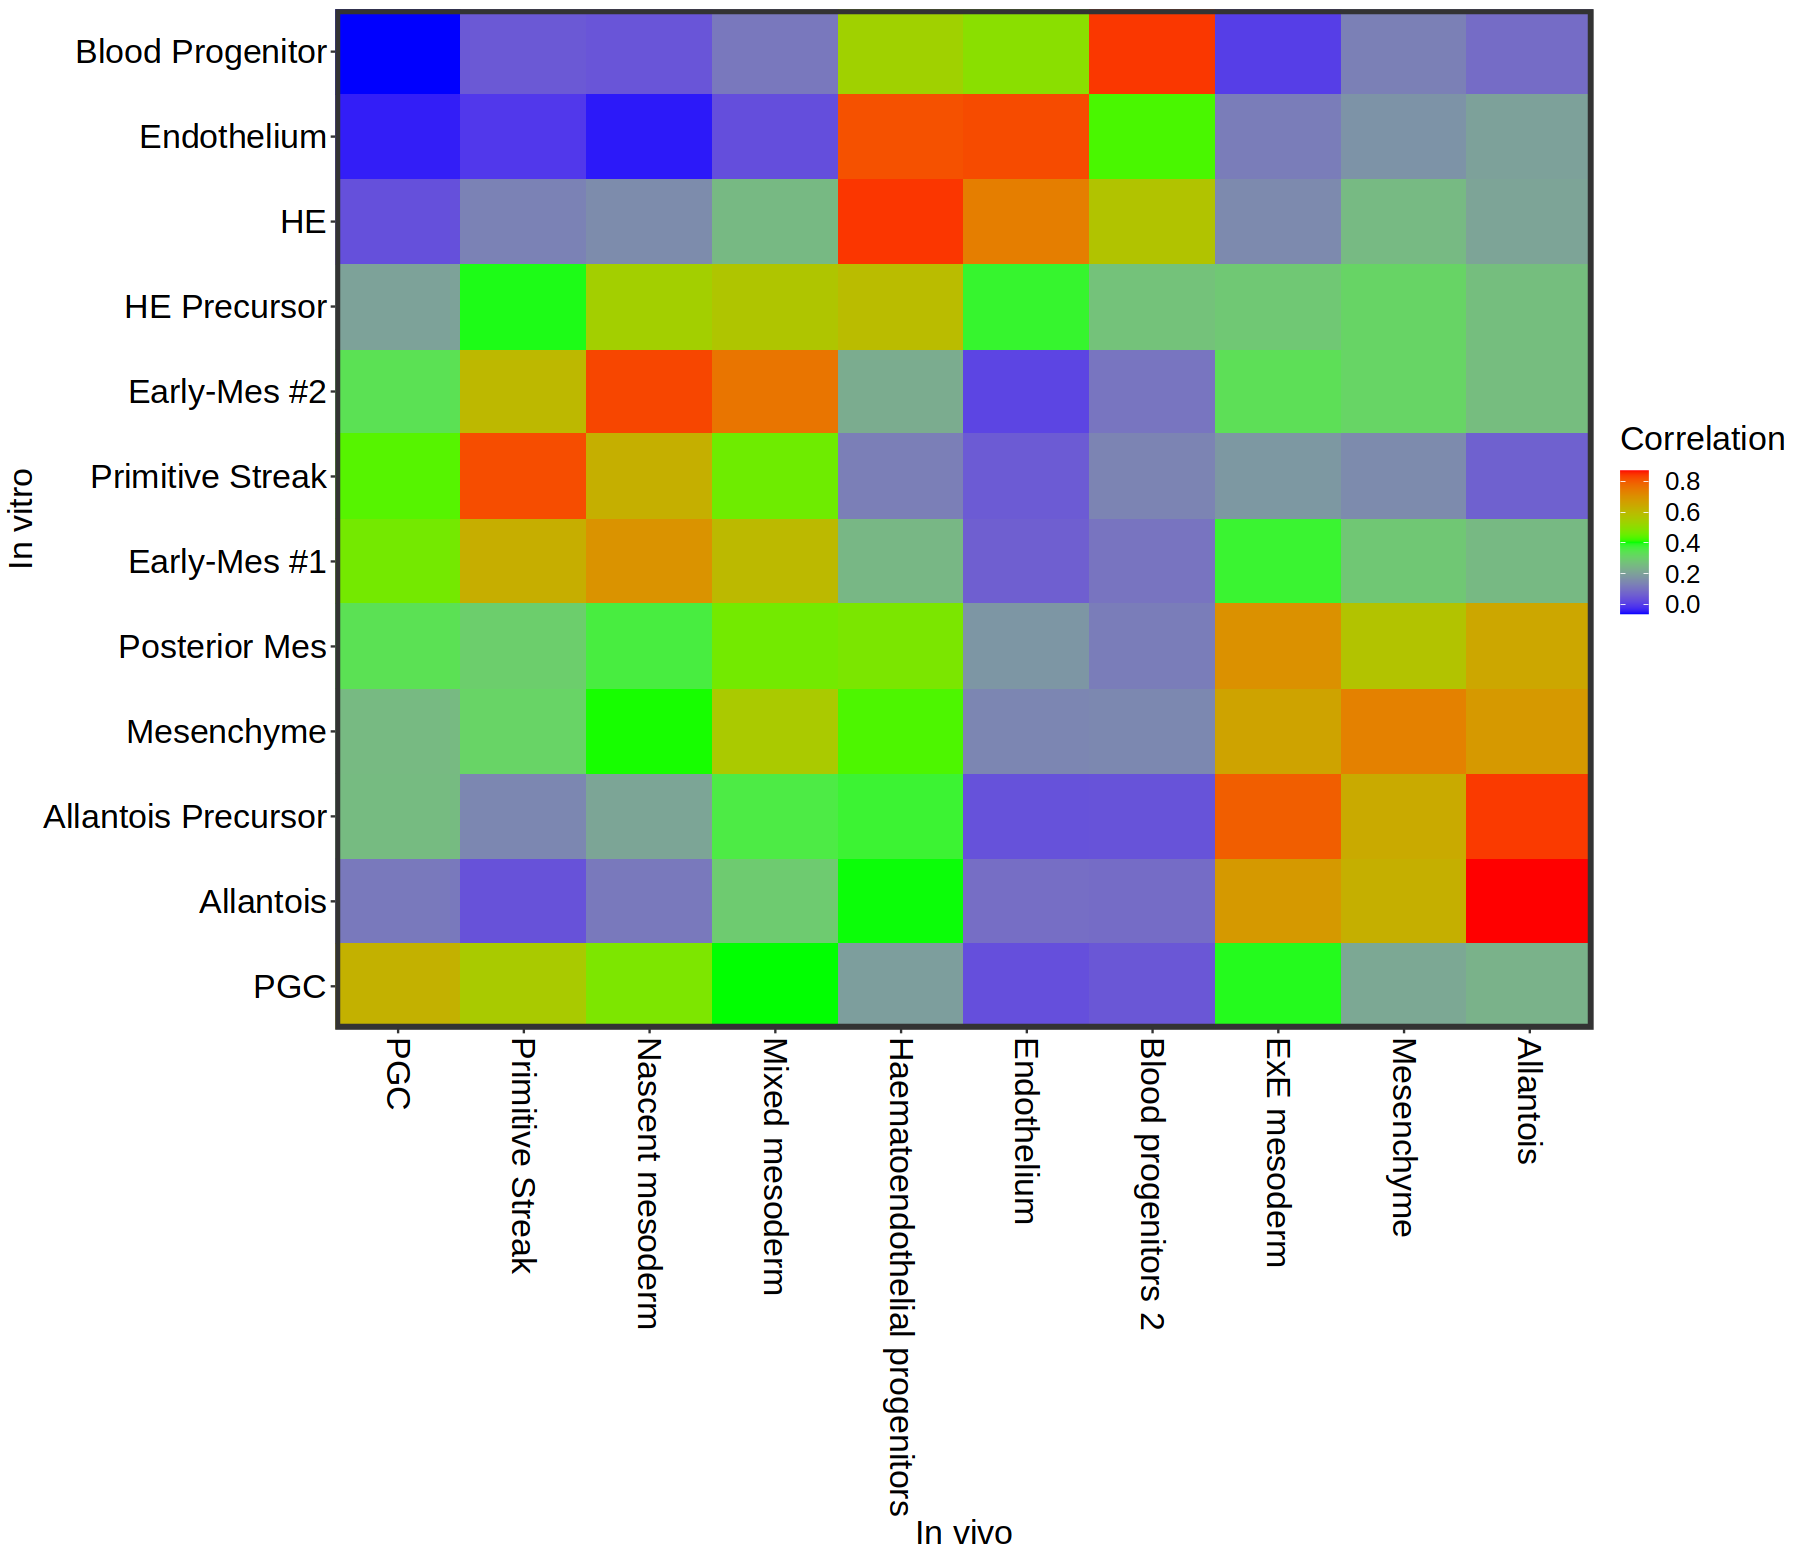

In [33]:
options(repr.plot.width=15, repr.plot.height=13)
p = ggplot(correlations, aes(atlas, vitro, fill=Correlation)) + 
    geom_tile() + 

    #scale_fill_gradientn(colors = c('blue', 'white',  'yellow', 'green', 'red')) + 
    scale_fill_gradientn(colors=rev(rainbow(3)), values = c(0, 0.5, 1)) + 
               #          limits=c(0,1),
               # breaks = c(0, 0.50, 1)) + 
    scale_x_discrete(expand=c(0,0)) + 
    scale_y_discrete(expand=c(0,0)) + 
    xlab('In vivo') + ylab('In vitro') + 
    theme_bw() + 
    theme(axis.text.x = element_text(angle=-90, hjust=0, vjust=0.5),
          axis.text = element_text(color='black', size = 20),
          axis.title = element_text(size=20),
          legend.text = element_text(size=15),
          legend.title = element_text(size=20),
          panel.border = element_rect(linewidth = 2))

# pdf(file.path(io$basedir, '/results/Suppl/mapping_correlation.pdf'), width=15, height=12)
#     print(p)
# dev.off()
p

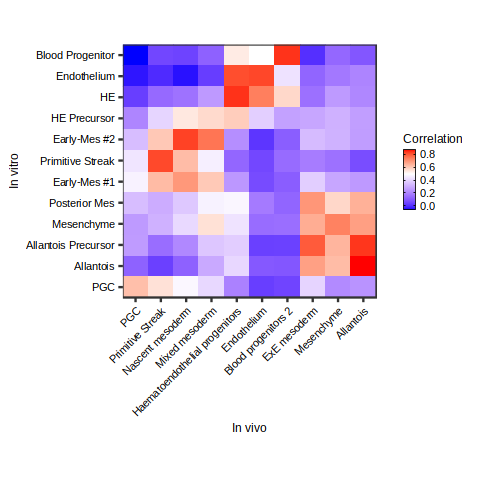

In [34]:
io$outdir = file.path(io$basedir, '/results/thesis/')

p = ggplot(correlations, aes(atlas, vitro, fill=Correlation)) + 
    geom_tile() + 

    #scale_fill_gradientn(colors = c('blue', 'white',  'yellow', 'green', 'red')) + 
    #scale_fill_gradientn(colors=rev(rainbow(3))) +
    scale_fill_gradientn(colors=c('blue', 'white', 'red'), values = c(0,0.6,1)) +
    guides(
        fill = guide_colourbar(
            barwidth = 0.5, barheight = 2.5,
            frame.colour = "black", 
            ticks.colour = "black",
            order = 2, 
        )) + 
               #          limits=c(0,1),
               # breaks = c(0, 0.50, 1)) + 
    scale_x_discrete(expand=c(0,0)) + 
    scale_y_discrete(expand=c(0,0)) + 
    xlab('In vivo') + ylab('In vitro') + 
    coord_fixed(ratio = 10/12) + 
    theme_bw() + 
    theme(axis.text.x = element_text(angle=45, hjust=1, vjust=1, size = 6),
          axis.text.y = element_text(size = 6),
          axis.text = element_text(color='black'),
          axis.title = element_text(size=7),
          legend.text = element_text(size=6),
          legend.title = element_text(size=7),
          panel.border = element_rect(linewidth = 0.5))

options(repr.plot.width=4, repr.plot.height=4)
p
ggsave(file.path(paste0(io$outdir, 'atlas_correlation_ATAC_v2.pdf')), 
       plot = p,
       width = 80, 
       height = 60, 
       units = "mm")

In [35]:
length(unique(marker_peaks$feature))

[1] 45512